In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [5]:
df = pd.read_csv("data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
X = df.drop(columns=['math score'])
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [9]:
y = df['math score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [15]:
# Create column transformer with 3 types of Transformers
num_features = X.select_dtypes(exclude='str').columns
cat_features = X.select_dtypes(include='str').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numerical_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScaler',numerical_transformer,num_features)
    ]
)

X = preprocessor.fit_transform(X)
print(X.shape)

(1000, 19)


In [16]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape,X_test.shape)

(800, 19) (200, 19)


### Create an Evaluation Function to give all metrics after model Training

In [17]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true,predicted)
    return mae,rmse,r2_square

In [26]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "XGBRegressor" : XGBRegressor(),
    "CatBoostRegressor" : CatBoostRegressor(),
    "AdaBoostRegressor" : AdaBoostRegressor()
}

model_list = []
r2_list = []


for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    #Make Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Evaluate Train and Test Dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train,y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance for Training Data")
    print(f" - Root Mean Squared Error: {model_train_rmse:.4f}")
    print(f" - Mean Absolute Error: {model_train_mae:.4f}")
    print(f" - R2 Score: {model_train_r2:.4f}")

    print('-----------------------------------------')

    print("Model Performance for Testing Data")
    print(f" - Root Mean Squared Error: {model_test_rmse:.4f}")
    print(f" - Mean Absolute Error: {model_test_mae:.4f}")
    print(f" - R2 Score: {model_test_r2:.4f}")

    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')



Linear Regression
Model Performance for Training Data
 - Root Mean Squared Error: 5.3231
 - Mean Absolute Error: 4.2667
 - R2 Score: 0.8743
-----------------------------------------
Model Performance for Testing Data
 - Root Mean Squared Error: 5.3940
 - Mean Absolute Error: 4.2148
 - R2 Score: 0.8804


Lasso
Model Performance for Training Data
 - Root Mean Squared Error: 6.5938
 - Mean Absolute Error: 5.2063
 - R2 Score: 0.8071
-----------------------------------------
Model Performance for Testing Data
 - Root Mean Squared Error: 6.5197
 - Mean Absolute Error: 5.1579
 - R2 Score: 0.8253


Ridge
Model Performance for Training Data
 - Root Mean Squared Error: 5.3233
 - Mean Absolute Error: 4.2650
 - R2 Score: 0.8743
-----------------------------------------
Model Performance for Testing Data
 - Root Mean Squared Error: 5.3904
 - Mean Absolute Error: 4.2111
 - R2 Score: 0.8806


K-Nearest Neighbors
Model Performance for Training Data
 - Root Mean Squared Error: 5.7077
 - Mean Absolute E

#### Results

In [27]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name',"R2 Score"]).sort_values(by=['R2 Score'],ascending=False)

,Model Name,R2 Score
2,Ridge,0.880593
0,Linear Regression,0.880433
7,CatBoostRegressor,0.851632
5,Random Forest Regressor,0.848716
8,AdaBoostRegressor,0.845349
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Nearest Neighbors,0.783813
4,Decision Tree,0.744985


### Linear Regression

In [31]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print(f"Accuracy of the Model is {score:.2f} %")

Accuracy of the Model is 88.04 %


### Plot y_test and y_pred

Text(0, 0.5, 'Predicted')

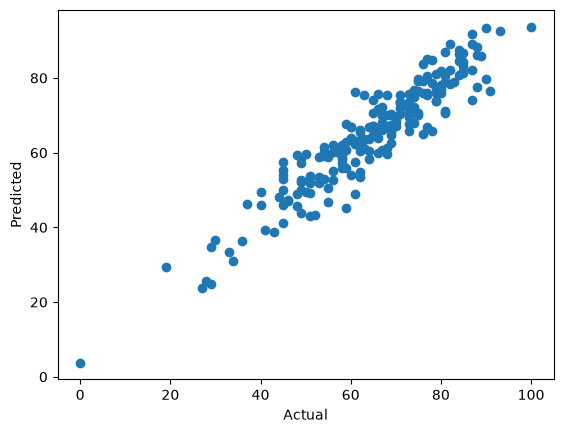

In [32]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math score'>

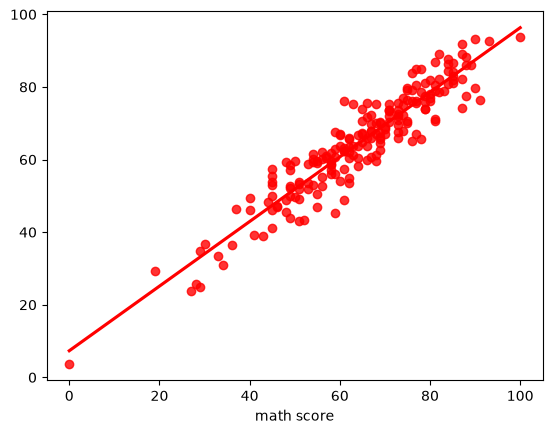

In [33]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

Difference Between Actual and Predicted Values

In [35]:
pred_df = pd.DataFrame({"Actual":y_test,"Predicted":y_pred,"Difference":y_test-y_pred})
pred_df

,Actual,Predicted,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
